This is a short tutorial notebook explaining how to use the code base to train, evaluate and analyse results.

First install hardware specific jax packages.


In [ ]:
%pip install -U "jax[cuda12]"

We will start by training and evaluating a small 100 agent stochastic block model (SBM) graph. Note that different seeds can find different optimisations and we choose seed 2 here to demonstrate some interesting learned behaviour.

In [1]:
import os
cwd = os.getcwd()
base_dir = os.path.dirname(cwd)

In [2]:
print("Starting training")
%run ../scripts/train.py +graph=generate/100_agents/sbm path.BASE_DIR=$base_dir train.seed.SEEDS=[2]
print("Training finished")

Starting training


  GPU 0  
         

padded_alphas: [0.  0.2 0.4 0.6 0.8 1. ]
Starting run for seed 2


2026-06-03 13:56:03.728612: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 13:56:03.728680: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 13:56:03.728743: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 13:56:03.728777: W external/xla/xla/service/gpu/au

Training finished


In [3]:
print("Starting evaluation")
%run ../scripts/eval.py +graph=generate/100_agents/sbm path.BASE_DIR=$base_dir train.seed.SEEDS=[2]
print("Evaluation finished")

Starting evaluation
Starting run for seed 2
shape own_id: (1, 1000)
shape neighbour_acitons: (1, 1000, 100)


2026-06-03 14:26:39.460486: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 14:26:39.460539: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 14:26:39.460559: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-06-03 14:26:39.460575: W external/xla/xla/service/gpu/au

Evaluation finished


Let's see how well the population trained.

Text(0, 0.5, 'Mean Reward per\nAgent per Timestep')

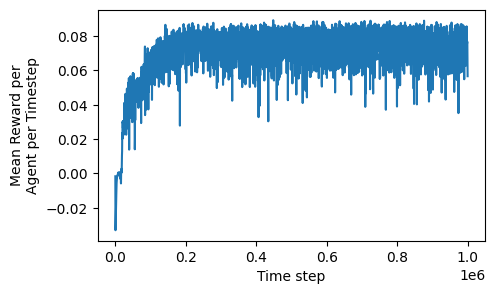

In [9]:

from pathlib import Path
import pickle as pkl
import matplotlib.pyplot as plt

BASE_DIR = Path(base_dir)
graph = "sbm/seed_0/num_communities_5/p_in_0.33/p_ext_0.005"
alpha = 1.0
seed = 2

training_metrics_path = BASE_DIR / "output_data" / "train" / "ppo_other_play" / f"graph_{graph}" / f"num_agents_100" / f"alpha_{alpha:.2f}" / f"seed_{seed}"
with open(training_metrics_path / "metrics.pkl", "rb") as f:
    training_metrics = pkl.load(f)

rewards = training_metrics["normalised_returns"]
timesteps = training_metrics["total_step"]

fig, ax = plt.subplots(1, figsize=(5, 3))
ax.plot(timesteps, rewards)
ax.set_xlabel("Time step")
ax.set_ylabel("Mean Reward per\nAgent per Timestep")

We see the population training has stabilised to a policy with high returns. (The maximum reward per step is 0.1)

Let's see what an episode looks like!

In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
import numpy as np
import pickle as pkl
from pathlib import Path
from opinimarl.graphs import make_graph
from IPython.display import HTML

def animate_graph_gif(adj_matrix, outputs_series, out_path, pos=None, dpi=400, fps=3):
    """
    adj_matrix: (N, N) adjacency matrix
    outputs_series: (T, N) array of node outputs over time, values in {0, 1, 2}
    out_path: path to .gif
    """
    colors_output = ["coral", "mediumturquoise", "gainsboro"]

    G = nx.from_numpy_array(np.asarray(adj_matrix))
    if pos is None:
        pos = nx.spring_layout(G, seed=14)

    T = outputs_series.shape[0]
    fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=dpi)
    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.02)

    legend_elements = [
        plt.Line2D([0], [0], marker='o', label='0',
                   markerfacecolor=colors_output[0], markersize=8,
                   linestyle='None', markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', label='1',
                   markerfacecolor=colors_output[1], markersize=8,
                   linestyle='None', markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', label=r'$\emptyset$',
                   markerfacecolor=colors_output[2], markersize=8,
                   linestyle='None', markeredgecolor='black'),
    ]

    def update(step):
        ax.clear()
        node_colors = [colors_output[o] for o in outputs_series[step]]

        nx.draw(
            G,
            pos,
            ax=ax,
            with_labels=False,
            node_color=node_colors,
            edge_color="gray",
            node_size=25,
            linewidths=0.6,
            edgecolors="black",
        )

        ax.set_title(f"Step {step + 1}", fontsize=10)
        ax.set_axis_off()

        ax.legend(
            handles=legend_elements,
            loc="lower center",
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.02),
            fontsize=8,
        )

    ani = animation.FuncAnimation(fig, update, frames=T, interval=350, blit=False, repeat=True)

    ani.save(
        out_path,
        writer="pillow",
        fps=fps,
        dpi=dpi,
        savefig_kwargs={"transparent": False, "bbox_inches": None, "pad_inches": 0},
    )

    plt.close(fig)


BASE_DIR = Path(base_dir)
graph = "sbm/seed_0/num_communities_5/p_in_0.33/p_ext_0.005"
alpha = 1.0
seed = 2
env = 1
metrics_path = BASE_DIR / "output_data" / "eval" / "ppo_other_play" / "eval_op_true" / f"graph_{graph}" / f"num_agents_100" / f"alpha_{alpha:.2f}" / f"seed_{seed}"
with open(metrics_path / "metrics.pkl", "rb") as f:
    metrics = pkl.load(f)

outputs_series = np.array(metrics["outputs"][:, env])

adj_matrix, _ = make_graph("sbm", num_nodes=100, seed=0, num_communities=5, p_in=0.33, p_ext=0.005)
animate_graph_gif(adj_matrix, outputs_series, "../examples/graph_animation.gif")

print(fr"alpha = {alpha:.2f}")
print(f"Ground truth = {metrics['ground_truth'][0, env]}")
HTML('<img src="../examples/graph_animation.gif", width=600>')

[2026-06-03 14:34:55,912][matplotlib.animation][INFO] - Animation.save using <class 'matplotlib.animation.PillowWriter'>
[2026-06-03 14:34:55,913][matplotlib.animation][WARNING] - Warning: discarding the 'bbox_inches' argument in 'savefig_kwargs' as it may cause frame size to vary, which is inappropriate for animation.
alpha = 1.00
Ground truth = 0


Truth-seeking agents ($\alpha = 1$) successfully find the ground-truth value which in this case is 0. 

We can also plot the perceived importance centrality metric against the node degree to uncover some interesting learned behaviours.

alpha = 0.0, Weight = 0.9500185251235962 +/- 0.2801632285118103
alpha = 0.0, Weight = 0.9706888794898987 +/- 0.18185144662857056
alpha = 0.0, Weight = 0.9870072603225708 +/- 0.04792650416493416
alpha = 1.0, Weight = 0.8153738975524902 +/- 0.16111205518245697
alpha = 1.0, Weight = 1.191123127937317 +/- 0.19793084263801575
alpha = 1.0, Weight = 1.4956462383270264 +/- 0.06741858273744583


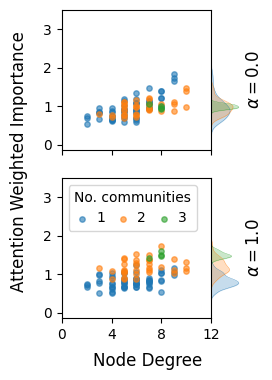

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import pickle as pkl
import jax.numpy as jnp
import jax
import numpy as np
import networkx as nx
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
import opinimarl.graphs as graph_gen
from opinimarl.graphs import make_graph

BASE_DIR = Path(base_dir)

seed = 2 # 4

# 100 agents
num_agents = 100

graph = "sbm/seed_0/num_communities_5/p_in_0.33/p_ext_0.005"
adj_matrix, _ = make_graph("sbm", num_nodes=100, seed=0, num_communities=5, p_in=0.33, p_ext=0.005)

experts = False
experts_dir = "experts" if experts else "no_experts"

alphas = [0.0, 1.0]
timesteps = [0, 360, 1600]

fig, axs = plt.subplots(2, 1, figsize=(2.3, 4), sharex=True, sharey=True)
# fig.suptitle(f"{num_agents} agents, SBM graph", x=0.5, y=1.04)
fig.subplots_adjust(wspace=0.05, hspace=0.2)

for k, alpha in enumerate(alphas):
    metrics_path = BASE_DIR / "output_data" / "eval" / "ppo_other_play" / "eval_op_true" / f"graph_{graph}" / f"num_agents_100" / f"alpha_{alpha:.2f}" / f"seed_{seed}"
    with open(metrics_path / "metrics.pkl", "rb") as f:
        metrics = pkl.load(f)
    
    attn_weights = metrics["attn_weights"]

    degrees = adj_matrix.sum(axis=0)
    received_attention_normalised = attn_weights.sum(axis=0) / degrees
    importance_weighted_attn_weights = attn_weights * jnp.tile((degrees+1), (num_agents, 1)).T
    received_importance_weighted_attn_weights_normalised = importance_weighted_attn_weights.sum(axis=0) / jnp.maximum((degrees+1), 1)

    G = nx.from_numpy_array(np.array(adj_matrix))

    # SBM inter-community nodes
    num_communities = 5
    inter_community_nodes = {}
    for i in np.arange(num_agents):
        for j in np.arange(num_agents):
            i_community = i // (num_agents / num_communities)
            j_community = j // (num_agents / num_communities)

            if (i_community != j_community) and (adj_matrix[i, j] == 1):
                if i in inter_community_nodes.keys():
                    if j_community not in inter_community_nodes[i]:
                        inter_community_nodes[i].append(j_community)
                else:
                    inter_community_nodes[i] = [j_community]
                if j in inter_community_nodes.keys():
                    if i_community not in inter_community_nodes[j]:
                        inter_community_nodes[j].append(i_community)
                else:
                    inter_community_nodes[j] = [i_community]

    inter_community_nodes_num = {k: len(v) for k, v in inter_community_nodes.items()}
    inter_community_nodes_num_0 = jnp.array([node for node, num in inter_community_nodes_num.items() if num == 1])
    inter_community_nodes_num_1 = jnp.array([node for node, num in inter_community_nodes_num.items() if num == 2])
    inter_community_nodes = jnp.concatenate([inter_community_nodes_num_0, inter_community_nodes_num_1])
    expert_nodes = jnp.array([10, 20, 30]) if experts else jnp.array([], dtype=jnp.int32)

    selected_degrees = jnp.take(degrees, inter_community_nodes)
    selected_weights = jnp.take(received_importance_weighted_attn_weights_normalised, inter_community_nodes)

    selected_degrees_0 = jnp.take(degrees, inter_community_nodes_num_0)
    selected_weights_0 = jnp.take(received_importance_weighted_attn_weights_normalised, inter_community_nodes_num_0)
    selected_degrees_1 = jnp.take(degrees, inter_community_nodes_num_1)
    selected_weights_1 = jnp.take(received_importance_weighted_attn_weights_normalised, inter_community_nodes_num_1)

    expert_degrees = jnp.take(degrees, expert_nodes)
    expert_weights = jnp.take(received_importance_weighted_attn_weights_normalised, expert_nodes)

    unselected_degrees = jnp.delete(degrees, inter_community_nodes)
    unselected_degrees = jnp.delete(unselected_degrees, expert_nodes)
    unselected_weights = jnp.delete(received_importance_weighted_attn_weights_normalised, inter_community_nodes)
    unselected_weights = jnp.delete(unselected_weights, expert_nodes)

    axs[k].scatter(unselected_degrees, unselected_weights, marker="o", s=15, color="C0", label="1", alpha=0.6)
    axs[k].scatter(selected_degrees_0, selected_weights_0, marker="o", s=15, color="C1", label="2", alpha=0.6)
    axs[k].scatter(selected_degrees_1, selected_weights_1, marker="o", s=15, color="C2", label="3", alpha=0.6)
    axs[k].scatter(expert_degrees, expert_weights, marker="o", s=15, color="C3", alpha=0.6)
    axs[k].tick_params(axis='both', labelsize=10)

    print(f"alpha = {alpha}, Weight = {unselected_weights.mean()} +/- {unselected_weights.std()}")
    print(f"alpha = {alpha}, Weight = {selected_weights_0.mean()} +/- {selected_weights_0.std()}")
    print(f"alpha = {alpha}, Weight = {selected_weights_1.mean()} +/- {selected_weights_1.std()}")

    # Side axis
    divider = make_axes_locatable(axs[k])
    ax_dist = divider.append_axes("right", size=0.3, pad=-0.01, sharey=axs[k])

    # KDE
    kde = gaussian_kde(unselected_weights)
    y_vals = np.linspace(max(min(unselected_weights)-1, 0), min(max(unselected_weights)+1, 3), 200)
    pdf = kde(y_vals)

    kde_0 = gaussian_kde(selected_weights_0)
    y_vals_0 = np.linspace(max(min(selected_weights_0)-1, 0), min(max(selected_weights_0)+1, 3), 200)
    pdf_0 = kde_0(y_vals_0) * np.log1p(selected_weights_0.size) / np.log1p(unselected_weights.size)

    kde_1 = gaussian_kde(selected_weights_1)
    y_vals_1 = np.linspace(max(min(selected_weights_1)-1, 0), min(max(selected_weights_1)+1, 3), 200)
    pdf_1 = kde_1(y_vals_1) * np.log1p(selected_weights_1.size) / np.log1p(unselected_weights.size)

    # Plot shaded KDE
    ax_dist.plot(pdf, y_vals, color="C0", linewidth=0.2)
    ax_dist.fill_betweenx(y_vals, 0, pdf, color="C0", alpha=0.25, linewidth=0)

    ax_dist.plot(pdf_0, y_vals_0, color="C1", linewidth=0.2)
    ax_dist.fill_betweenx(y_vals_0, 0, pdf_0, color="C1", alpha=0.25, linewidth=0)
    
    ax_dist.plot(pdf_1, y_vals_1, color="C2", linewidth=0.2)
    ax_dist.fill_betweenx(y_vals_1, 0, pdf_1, color="C2", alpha=0.25, linewidth=0)

    ax_dist.axis("off")
    axs[k].set_zorder(1)
    axs[k].set_xticks([0, 4, 8, 12])
    axs[k].set_yticks([0, 1, 2, 3])


fig.supylabel("Attention Weighted Importance", x=-0.1, fontsize=12)
fig.supxlabel("Node Degree", y=-0.02, fontsize=12)
axs[1].legend(
    title="No. communities",
    loc="upper left",
    fontsize=10,
    title_fontsize=10,
    ncol=3,
    columnspacing=1.0,
    handlelength=0.5,
)

axs[0].set_ylim(top=3.5)
axs[1].set_ylim(top=3.5)

nrows = len(alphas)
for k, alpha in enumerate(alphas):
    # Get the position of the first axis in the row
    bbox = axs[k].get_position()
    y = bbox.y0 + bbox.height / 2   # vertical center of the row
    fig.text(0.92, y, f"$\\alpha = {alpha}$", va="center", fontsize=12, rotation=90)


As we see fromt he plots, the conforming agents ($\alpha = 0$) have learned to place more importance on nodes that have greater degree, as these can quickly inluence a large number of nodes for quick consensus formation. However, truth-seeking populations ($\alpha = 1$) learn to place more importance on nodes that bridge multiple clusters, in order to propagate infromation effectively between groups for a more accurate guess of the ground-truth.